# CMS-1500 Data Extraction Pipeline

This notebook implements a full pipeline to extract data from scanned CMS-1500 (HCFA 1500) forms using a template alignment and coordinate-based extraction approach.

**Approach:**
1.  **Alignment**: Align the scanned image to a reference template using ORB feature matching and Homography.
2.  **Extraction**: Extract specific regions of interest (ROIs) based on fixed coordinates from the template.
3.  **OCR**: Use Tesseract OCR to read text from the aligned ROIs.
4.  **Parsing**: Parse extracted text (e.g., currency) and detect checkbox states using pixel density.

**Dependencies:**
*   opencv-python
*   pytesseract
*   pandas


In [ ]:
!apt-get install tesseract-ocr -y
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
import cv2
import pytesseract
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re

# pytesseract.pytesseract.tesseract_cmd = r'/usr/bin/tesseract'

## 1. Load Images

We expect two images in the current directory:
1.  `cms_template.jpg`: The reference template image.
2.  `scan.png`: The scanned form to process.

In [ ]:
TEMPLATE_PATH = 'cms_template.jpg'
SCAN_PATH = 'scan.png'

# Helper to display images in notebook
def show_image(img, title="Image", cmap=None):
    plt.figure(figsize=(10, 10))
    if len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

if not os.path.exists(TEMPLATE_PATH):
    # Fallback to check if user uploaded with .png extension
    if os.path.exists('cms_template.png'):
        TEMPLATE_PATH = 'cms_template.png'

if not os.path.exists(SCAN_PATH):
    raise FileNotFoundError(f"Scan file '{SCAN_PATH}' not found. Please upload it.")

template = cv2.imread(TEMPLATE_PATH)
scan = cv2.imread(SCAN_PATH)

print(f"Loaded Template: {TEMPLATE_PATH}")
print(f"Loaded Scan: {SCAN_PATH}")

Loaded Template: cms_template.jpg
Loaded Scan: scan.png


## 2. Image Alignment (Registration)

We use ORB (Oriented FAST and Rotated BRIEF) feature matching to find keypoints in both images and compute a Homography matrix to warp the scan to match the template's perspective.

Aligning images...


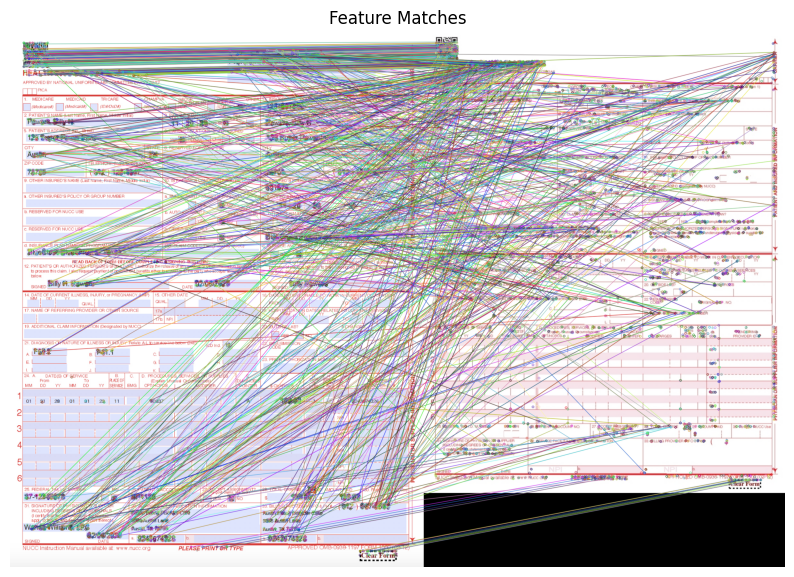

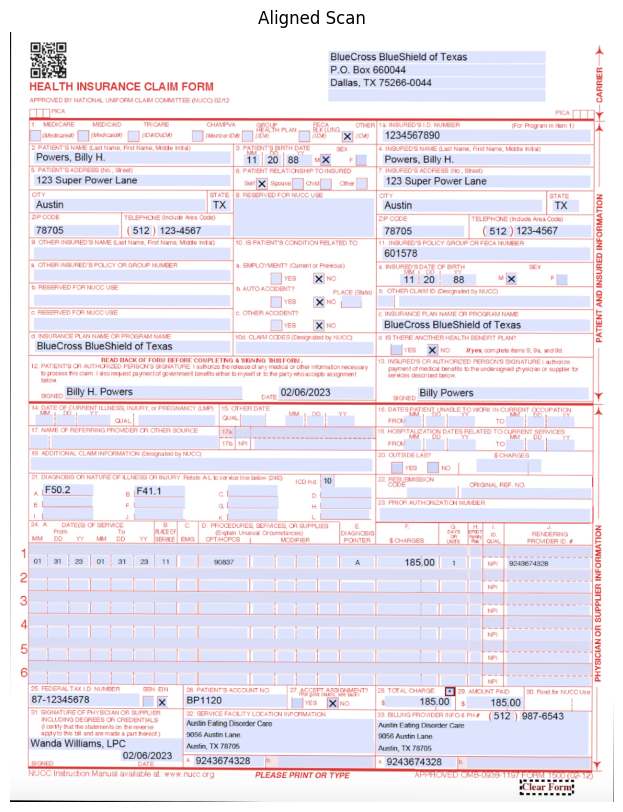

In [ ]:
def align_images(img, template, max_features=5000, keep_percent=0.2, debug=False):
    # Convert images to grayscale
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

    # Detect ORB features and compute descriptors
    orb = cv2.ORB_create(max_features)
    keypoints1, descriptors1 = orb.detectAndCompute(img_gray, None)
    keypoints2, descriptors2 = orb.detectAndCompute(template_gray, None)

    # Match features using Hamming distance
    matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)
    matches = matcher.match(descriptors1, descriptors2, None)

    # Sort matches by score
    matches = sorted(matches, key=lambda x: x.distance)

    # Keep only the top features
    keep = int(len(matches) * keep_percent)
    matches = matches[:keep]

    # Check if we have enough matches
    if len(matches) < 4:
        print("Not enough matches found to align images.")
        return img

    # Extract location of good matches
    points1 = np.zeros((len(matches), 2), dtype="float")
    points2 = np.zeros((len(matches), 2), dtype="float")

    for i, m in enumerate(matches):
        points1[i] = keypoints1[m.queryIdx].pt
        points2[i] = keypoints2[m.trainIdx].pt

    # Find homography
    H, mask = cv2.findHomography(points1, points2, cv2.RANSAC)

    # Use homography to warp image
    height, width = template.shape[:2]
    aligned_img = cv2.warpPerspective(img, H, (width, height))

    if debug:
        # Draw top matches
        matched_vis = cv2.drawMatches(img, keypoints1, template, keypoints2, matches, None)
        show_image(matched_vis, "Feature Matches")

    return aligned_img

print("Aligning images...")
aligned_scan = align_images(scan, template, debug=True)
show_image(aligned_scan, "Aligned Scan")

## 3. Define Regions of Interest (ROIs)


In [ ]:
# Coordinates format: (x, y, w, h)

ROIS = {
    "box_29": (790, 1188, 130, 30),
    "box_27_yes": (502, 1190, 22, 22),
    "box_27_no": (570, 1190, 22, 22)
}

def extract_roi(img, roi_coords):
    x, y, w, h = roi_coords
    return img[y:y+h, x:x+w]

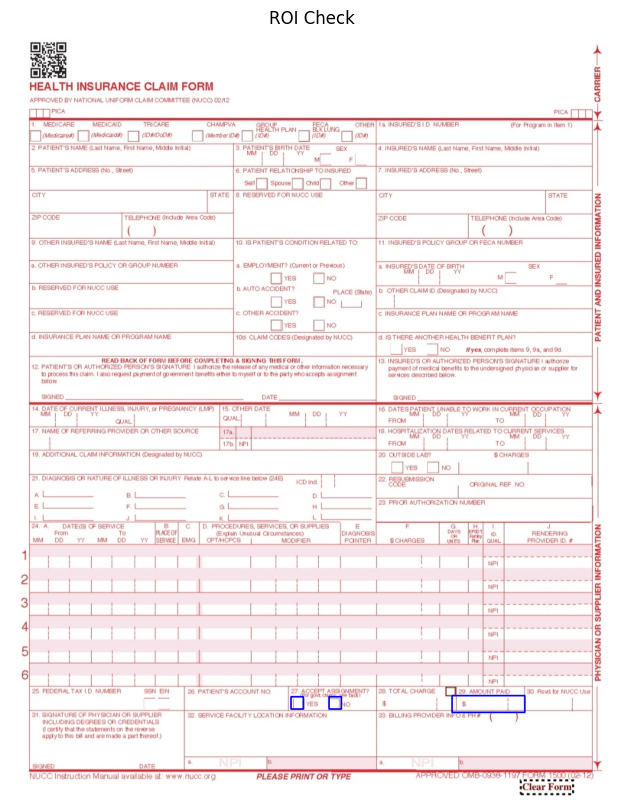

In [ ]:
import copy

debug_img = copy.deepcopy(template)

for key, (x,y,w,h) in ROIS.items():
    cv2.rectangle(debug_img, (x,y), (x+w, y+h), (255,0,0), 2)

plt.figure(figsize=(8,10))
plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
plt.title("ROI Check")
plt.axis("off")
plt.show()


## 4. Extraction Logic

### Text Extraction (Box 29)
Used `pytesseract` with configuration optimized for single blocks of text/digits.

### Checkbox Detection (Box 27)
Used pixel density and threshold the image (convert to black/white) and count the number of black pixels. A marked checkbox will have significantly more black pixels than an empty one.

In [ ]:
def preprocess_for_ocr(img):
    # Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3,3), 0)
    # Adaptive thresholding to handle uneven lighting
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    return thresh

def extract_amount(roi_img):
    # Preprocess
    processed = preprocess_for_ocr(roi_img)

    # OCR
    # config: --psm 7 (Treat the image as a single text line)
    text = pytesseract.image_to_string(processed, config='--psm 7')

    # Regex to find currency-like patterns (e.g., 200.00, 50.00)
    match = re.search(r'(\d+\.\d{2})', text)
    if match:
        return match.group(1)
    clean_text = re.sub(r'[^0-9.]', '', text)
    return clean_text

def is_checked(roi_img, threshold_percent=0.1):
    # Grayscale and Threshold (Inverse Binary: Black pixels become white)
    gray = cv2.cvtColor(roi_img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)

    # Calculate pixel density (ratio of white pixels to total pixels)
    total_pixels = thresh.size
    white_pixels = cv2.countNonZero(thresh)
    density = white_pixels / total_pixels
    return density > threshold_percent, density

## 5. Run Pipeline

Process the aligned image and extract the fields.

Extracted Amount Paid: 185.00


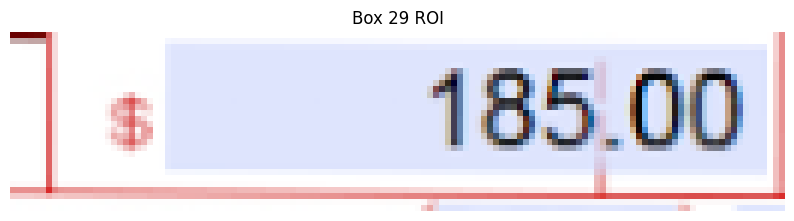

YES Density: 0.002, Checked: False
NO Density: 0.149, Checked: True


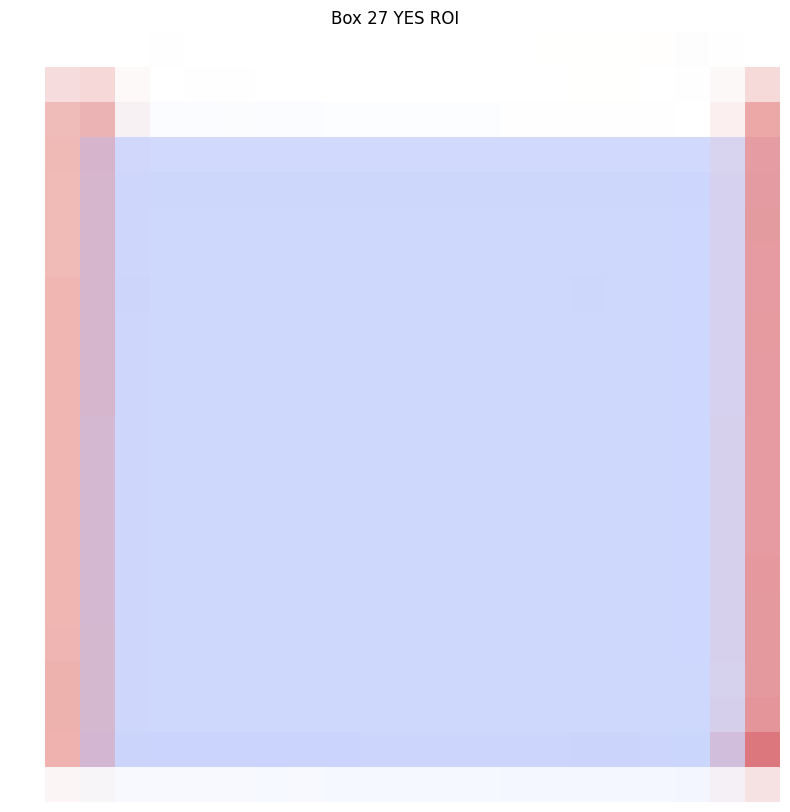

In [ ]:
results = {}

# 1. Box 29: Amount Paid
roi_29 = extract_roi(aligned_scan, ROIS['box_29'])
amount_paid = extract_amount(roi_29)
results['Amount Paid'] = amount_paid
print(f"Extracted Amount Paid: {amount_paid}")
show_image(roi_29, "Box 29 ROI")

# 2. Box 27: Accept Assignment
roi_27_yes = extract_roi(aligned_scan, ROIS['box_27_yes'])
roi_27_no = extract_roi(aligned_scan, ROIS['box_27_no'])

yes_checked, yes_density = is_checked(roi_27_yes)
no_checked, no_density = is_checked(roi_27_no)

print(f"YES Density: {yes_density:.3f}, Checked: {yes_checked}")
print(f"NO Density: {no_density:.3f}, Checked: {no_checked}")
show_image(roi_27_yes, "Box 27 YES ROI")

if yes_checked and not no_checked:
    results['Accept Assignment'] = "YES"
elif no_checked and not yes_checked:
    results['Accept Assignment'] = "NO"
elif yes_checked and no_checked:
    results['Accept Assignment'] = "AMBIGUOUS (BOTH)"
else:
    results['Accept Assignment'] = "UNCHECKED"

## 6. Export Results

Save the extracted data to a CSV file.

In [ ]:
data = {
    "Filename": [SCAN_PATH],
    "Form Type": ["HICF"],
    "Accept Assignment (Box 27)": [results.get('Accept Assignment', '')],
    "Amount Paid (Box 29)": [results.get('Amount Paid', '')]
}

df = pd.DataFrame(data)
print("Final DataFrame:")
print(df)

df.to_csv("output.csv", index=False)
print("Saved results to output.csv")

Final DataFrame:
   Filename Form Type Accept Assignment (Box 27) Amount Paid (Box 29)
0  scan.png      HICF                         NO               185.00
Saved results to output.csv
